In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
import seaborn as sns

# Add project root (one level above notebooks/) to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils import dimensionality_reduction_utils as dr_utils

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Features: {feature_names}")
print(f"TargetNames: {target_names}")

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
TargetNames: ['malignant' 'benign']


<div class='alert alert-info'>The Breast Cancer Wisconsin (Diagnostic) dataset contains features computed from digitized images of fine needle aspirate (FNA) of breast masses, describing characteristics of cell nuclei present in the images, used to predict whether a breast mass is benign or malignant.

Features

| Feature Name     | Description                                        | Value Range            |
|------------------|----------------------------------------------------|------------------------| 
| Radius           | Mean of distances from center to points on perimeter | Continuous           |
| Texture          | Standard deviation of gray-scale values            | Continuous             |
| Perimeter        | Perimeter of the cell nucleus                      | Continuous             |
| Area             | Area of the cell nucleus                           | Continuous             |
| Smoothness       | Local variation in radius lengths                  | Continuous             |
| Compactness      | (Perimeter² / Area) - 1.0                          | Continuous             |
| Concavity        | Severity of concave portions of the contour        | Continuous             |
| Concave points   | Number of concave portions of the contour          | Continuous             |
| Symmetry         | Symmetry of the cell nucleus                       | Continuous             |
| Fractal dimension| "Coastline approximation" - 1                      | Continuous             |

For each of the 10 real-valued features (radius through fractal dimension), three values are computed
* Mean
* Standard Error
* Worst or largest mean
</div>

In [4]:
df= pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Class Distribution: \n0->malignant\n1->benign\n{df['target'].value_counts()}")

Dataset shape: (569, 31)
Number of samples: 569
Class Distribution: 
0->malignant
1->benign
target
1    357
0    212
Name: count, dtype: int64


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

The dataset contains 569 samples with 31 continuous numerical features that describe various characteristics of cell nuclei, such as radius, texture, perimeter, and area, measured as mean, standard error, and worst values. All columns are complete with no missing values (569 non-null), and the data type is float64, making it clean and directly usable for analysis.

In [8]:
print(f"Dataset Statistics:")
print(df.describe().T)

Dataset Statistics:
                         count        mean         std         min  \
mean radius              569.0   14.127292    3.524049    6.981000   
mean texture             569.0   19.289649    4.301036    9.710000   
mean perimeter           569.0   91.969033   24.298981   43.790000   
mean area                569.0  654.889104  351.914129  143.500000   
mean smoothness          569.0    0.096360    0.014064    0.052630   
mean compactness         569.0    0.104341    0.052813    0.019380   
mean concavity           569.0    0.088799    0.079720    0.000000   
mean concave points      569.0    0.048919    0.038803    0.000000   
mean symmetry            569.0    0.181162    0.027414    0.106000   
mean fractal dimension   569.0    0.062798    0.007060    0.049960   
radius error             569.0    0.405172    0.277313    0.111500   
texture error            569.0    1.216853    0.551648    0.360200   
perimeter error          569.0    2.866059    2.021855    0.757000   


In [9]:
df[y == 0].head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [10]:
df[y == 1].head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
19,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,1
20,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,1
21,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,1
37,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,1
46,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,1


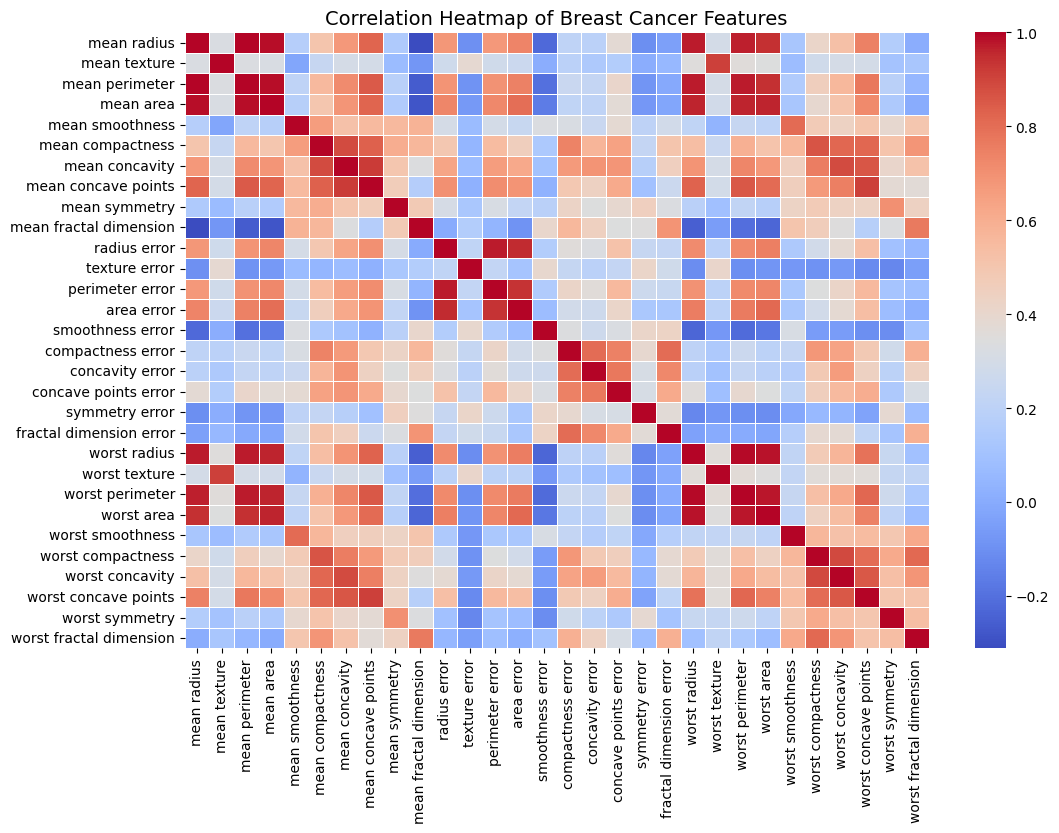

In [11]:
#Compute the correlation matrix
corr = df.iloc[:,:-1].corr()
# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Breast Cancer Features", fontsize=14)
plt.show()

From the correlation matrix above, we can identify clusters of highly correlated features. For instance, features related to the mean values (e.g., radius_mean, texture_mean, perimeter_mean) tend to be highly correlated with each other. Similarly, features related to the error and worst values (e.g.,radius_error,texture_error,perimeter_error, radius_worst, texture_worst, perimeter_worst) also show strong correlations among themselves. This indicates that these groups of features may provide redundant information, and we might drop these highly correlated features while performing any machine learning task. But for now, as a learning excercise, we will keep all the features and see how LDA performs.

<div class='alert alert-success'> Step 1 : Standardize the Data </div>

In [12]:
std_deviation = dr_utils.calculate_standard_deviation(X)
X_mean = np.mean(X, axis=0)
X_scaled = (X - X_mean) / std_deviation
print(f"Standard Deviation: {std_deviation}")
print(f"Features Mean:\n {X_mean}")    
print(f"Scaled Data:\n {X_scaled}")  

Standard Deviation: [3.52095076e+00 4.29725464e+00 2.42776193e+01 3.51604754e+02
 1.40517641e-02 5.27663291e-02 7.96497253e-02 3.87687325e-02
 2.73901809e-02 7.05415588e-03 2.77068942e-01 5.51163427e-01
 2.02007710e+00 4.54510134e+01 2.99987837e-03 1.78924359e-02
 3.01595231e-02 6.16486075e-03 8.25910439e-03 2.64374475e-03
 4.82899258e+00 6.14085432e+00 3.35730016e+01 5.68856459e+02
 2.28123569e-02 1.57198171e-01 2.08440875e-01 6.56745545e-02
 6.18130785e-02 1.80453893e-02]
Features Mean:
 [1.41272917e+01 1.92896485e+01 9.19690334e+01 6.54889104e+02
 9.63602812e-02 1.04340984e-01 8.87993158e-02 4.89191459e-02
 1.81161863e-01 6.27976098e-02 4.05172056e-01 1.21685343e+00
 2.86605923e+00 4.03370791e+01 7.04097891e-03 2.54781388e-02
 3.18937163e-02 1.17961371e-02 2.05422988e-02 3.79490387e-03
 1.62691898e+01 2.56772232e+01 1.07261213e+02 8.80583128e+02
 1.32368594e-01 2.54265044e-01 2.72188483e-01 1.14606223e-01
 2.90075571e-01 8.39458172e-02]
Scaled Data:
 [[ 1.09706398 -2.07333501  1.269

<div class='alert alert-success'> Step 2 : Compute the class means </div>

In [13]:
class_means = dr_utils.calculate_class_means(X_scaled, y)
print(f"Class Means:\n {class_means}")

Class Means:
 {np.int64(0): array([ 0.94734027,  0.53877588,  0.96370009,  0.92003111,  0.46529456,
        0.77410727,  0.90364908,  1.00779292,  0.42887995, -0.01665905,
        0.73595579, -0.01077503,  0.72169029,  0.71143247, -0.08696505,
        0.380218  ,  0.32925896,  0.52950663, -0.00846312,  0.10118291,
        1.00758521,  0.5929117 ,  1.01596866,  0.95226693,  0.54692472,
        0.76692406,  0.85596015,  1.02979135,  0.54021502,  0.42028107]), np.int64(1): array([-0.56256621, -0.31994534, -0.57228129, -0.54634901, -0.27630937,
       -0.45969395, -0.53662074, -0.59846526, -0.25468501,  0.00989277,
       -0.43703817,  0.00639862, -0.42856678, -0.4224753 ,  0.05164311,
       -0.22578772, -0.19552633, -0.31444091,  0.00502572, -0.06008621,
       -0.59834192, -0.35209322, -0.60332033, -0.56549185, -0.32478442,
       -0.45542829, -0.50830127, -0.61152876, -0.32079995, -0.24957868])}


<div class='alert alert-success'> Step 3 : Compute the covariance matrix of the classes </div>

In [14]:
class_covariances = dr_utils.compute_class_covariances(X_scaled,y)
for cls, cov in class_covariances.items():
    print(f"Covariance matrix for class {cls}:")
    print(cov)

Covariance matrix for class 0:
[[ 1.99978599e+02  1.33490581e+01  1.98483243e+02  2.22191458e+02
  -3.00062382e+01  4.58155720e+01  1.09364192e+02  1.44683114e+02
  -2.74904051e+01 -1.25404415e+02  1.62644358e+02 -3.69638153e+01
   1.61279185e+02  1.87449415e+02 -4.52420868e+01 -8.01356312e-01
   7.20223710e+00  3.50154101e+01 -3.67927176e+01 -4.21110982e+01
   1.86642468e+02 -1.57816256e+01  1.84406842e+02  2.06043365e+02
  -6.41686946e+01 -1.18370996e+01  3.02128832e+01  8.32079332e+01
  -6.63286696e+01 -1.01224997e+02]
 [ 1.33490581e+01  1.64067454e+02  1.36319441e+01  1.58725418e+01
  -2.21253042e+01  3.87294052e+00  7.68321048e+00 -2.57893312e+00
  -1.45263714e+01 -3.94945215e+00  7.14133046e+00  5.80098150e+01
   1.26041813e+01  1.06870225e+01  1.68611670e+01  2.72804748e+01
   1.83040302e+01  7.77407046e+00 -5.50304200e+00  1.61269707e+01
   1.52974460e+01  1.39207361e+02  1.66822545e+01  2.00108197e+01
  -3.52997679e+00  1.87193616e+01  1.43773553e+01 -6.03583687e+00
  -1.87613

<div class='alert alert-success'> Step 4 : Compute the within class scatter matrix </div>

In [15]:
n_features = X_scaled.shape[1]
scatter_matrix_SW = np.zeros((n_features,n_features))
for cls,cov in class_covariances.items():
    scatter_matrix_SW += cov
print(scatter_matrix_SW)

[[ 306.01616912    4.3769417   301.46716026  304.37887941  -67.84332331
    60.24747488  130.98429173  192.73485218  -73.4301246  -244.16088791
   166.4281111  -123.41376798  166.53187124  203.72176153 -179.19755188
   -30.37986154  -26.72356598   36.07115799 -127.86911882 -115.08263699
   276.4260598   -21.87239114  272.21531545  271.48968258 -113.4513796
     8.98504221   55.4215191   143.69807387  -86.85832179 -151.72482571]
 [   4.3769417   472.27392241    4.32069213    8.39928736  -95.08320795
    -9.92439972    1.1104523   -25.17395521  -33.73885675  -27.20682847
    20.12383372  234.92622114   26.32910083   15.99601119   34.35403496
    44.7685801    27.43720988   -1.60886791   19.8116978    23.29545042
     8.50126796  411.21250713    9.90603386   14.62028367  -54.2846754
    14.93861065   10.02112632  -28.59621321  -37.26939175   -4.78859308]
 [ 301.46716026    4.32069213  299.35884106  300.56635709  -50.29140788
    85.83119923  150.05835244  205.59339539  -56.68107163 -218.9

<div class='alert alert-success'> Step 5 : Compute the between class scatter matrix </div>

In [16]:
overall_mean = X_scaled.mean()
unique_classes = np.unique(y)
scatter_matrix_SB = np.zeros((n_features,n_features))
for cls in unique_classes:
    n_samples_perclass = X_scaled[y == cls].shape[0]
    mean_diff = class_means[cls] - overall_mean
    scatter_matrix_SB += n_samples_perclass * np.outer(mean_diff,mean_diff)
print(f'Between class scatter matrix is: {scatter_matrix_SB}')

Between class scatter matrix is: [[ 3.03243786e+02  1.72462254e+02  3.08480568e+02  2.94502118e+02
   1.48940870e+02  2.47791871e+02  2.89258229e+02  3.22594690e+02
   1.37284546e+02 -5.33256330e+00  2.35579576e+02 -3.44909012e+00
   2.31013186e+02  2.27729657e+02 -2.78375275e+01  1.21707849e+02
   1.05395849e+02  1.69495163e+02 -2.70904754e+00  3.23886680e+01
   3.22528202e+02  1.89791137e+02  3.25211746e+02  3.04820810e+02
   1.75070697e+02  2.45492526e+02  2.73992994e+02  3.29636391e+02
   1.72922922e+02  1.34532045e+02]
 [ 1.72462254e+02  9.80835561e+01  1.75440541e+02  1.67490650e+02
   8.47063623e+01  1.40925376e+02  1.64508321e+02  1.83467592e+02
   7.80771224e+01 -3.03276085e+00  1.33979941e+02 -1.96158300e+00
   1.31382922e+02  1.29515497e+02 -1.58318915e+01  6.92182691e+01
   5.99412304e+01  9.63960984e+01 -1.54070245e+00  1.84202378e+01
   1.83429779e+02  1.07938922e+02  1.84955977e+02  1.73359146e+02
   9.95670424e+01  1.39617681e+02  1.55826603e+02  1.87472382e+02
   9.834

<div class='alert alert-success'> Step 6 : Calculate the eigenvalues and eigenvectors </div>

In [17]:
scatter_matrix_SW_inv = np.linalg.inv(scatter_matrix_SW)
eigenValues, eigenvectors = dr_utils.calculate_eigen_decompostion(np.dot(scatter_matrix_SW_inv,scatter_matrix_SB))
print(f"Eigenvalues: {eigenValues}")
print(f"Eigenvectors:\n{eigenvectors}")

Eigenvalues: [ 3.03044947e+00+0.00000000e+00j  3.10505519e-13+3.05807992e-13j
  3.10505519e-13-3.05807992e-13j  3.92639334e-14+0.00000000e+00j
  2.36099665e-14+0.00000000e+00j  4.67155901e-15+9.46858362e-16j
  4.67155901e-15-9.46858362e-16j  1.59641475e-15+2.85187627e-15j
  1.59641475e-15-2.85187627e-15j  5.62178542e-16+1.82230792e-15j
  5.62178542e-16-1.82230792e-15j  2.46139461e-16+7.15893651e-16j
  2.46139461e-16-7.15893651e-16j  4.85917761e-17+0.00000000e+00j
 -5.42734364e-18+0.00000000e+00j -3.62942591e-17+0.00000000e+00j
 -2.12117123e-16+3.18424195e-15j -2.12117123e-16-3.18424195e-15j
 -9.04362585e-16+0.00000000e+00j -1.09271794e-15+2.61523982e-15j
 -1.09271794e-15-2.61523982e-15j -2.31599376e-15+0.00000000e+00j
 -3.84664382e-15+0.00000000e+00j -5.06718784e-15+3.05312693e-14j
 -5.06718784e-15-3.05312693e-14j -1.75404845e-14+0.00000000e+00j
 -1.98825258e-14+0.00000000e+00j -3.64968448e-14+3.33551546e-14j
 -3.64968448e-14-3.33551546e-14j -8.33837234e-14+0.00000000e+00j]
Eigenvector

In [18]:
# Remove near zero eigenvalues
eigenValues = eigenValues[eigenValues > 1e-10]

In [19]:
print(f"eigenValues after removing zeros: {eigenValues}")

eigenValues after removing zeros: [3.03044947+0.j]


As we have only 2 classes, we can have at most 1 LDA component. So we will select the eigenvector corresponding to the largest eigenvalue. Also, from the above output, we can see that there is only one significant eigenvalue, which further confirms that we can only have one LDA component.

In [20]:
explained_var_ratio = eigenValues / np.sum(eigenValues)
print(explained_var_ratio)

[1.+0.j]


In [21]:
#Get the first eigenvector and convert to real if imaginary parts are negligible
eigenvector_1 = eigenvectors[:, 0]
# Convert to real if the imaginary parts are essentially zero (e.g. 1+0.j -> 1.0)
eigenvector_1 = np.real_if_close(eigenvector_1)
# Ensure dtype is float (drop any tiny imaginary residues)
eigenvector_1 = np.asarray(eigenvector_1, dtype=float)
print("First eigenvector (real-valued):", eigenvector_1)

First eigenvector (real-valued): [ 0.50000401  0.03239674 -0.32835823 -0.14914454 -0.00533893 -0.24770899
  0.02819886  0.09627555  0.00905339  0.10894913  0.0379267   0.01198236
 -0.0091721   0.02589237  0.0615938  -0.01839174 -0.06015994  0.04683772
  0.0194173  -0.01688401  0.59182243  0.02917701  0.00907605 -0.39464692
  0.02104306  0.07124625  0.08829509  0.01014306  0.03662893  0.0290201 ]


In [22]:
# Project data onto the real-valued first eigenvector
X_lda_1d = X_scaled @ eigenvector_1

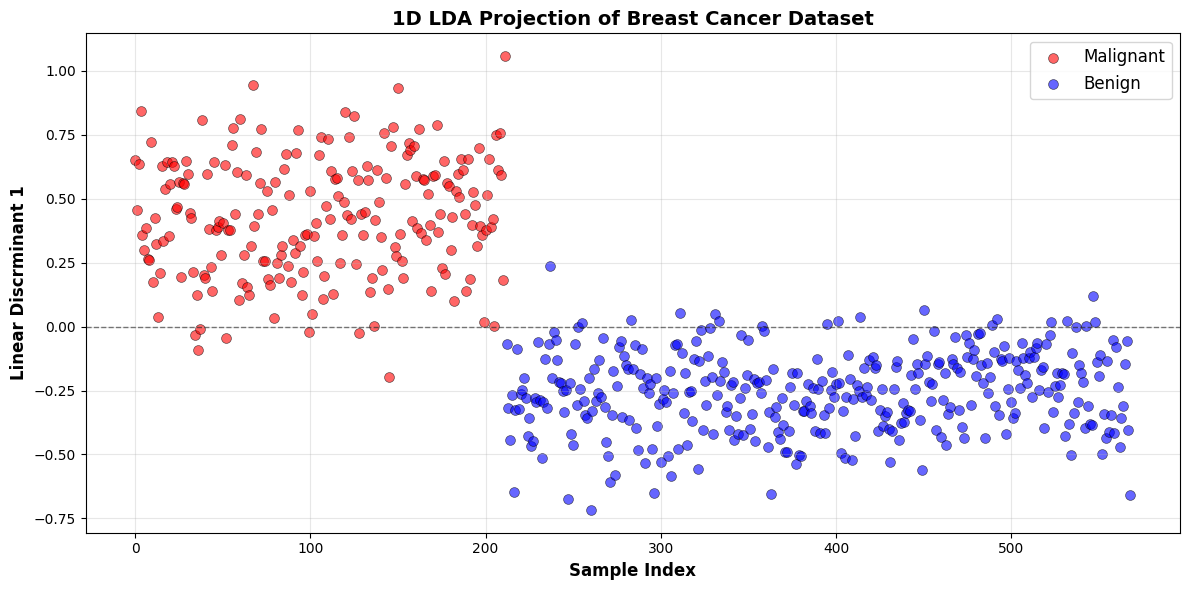

In [23]:
# Visualize the 1D LDA projection
fig, ax = plt.subplots(figsize=(12, 6))

# Plot malignant samples
malignant_mask = y == 0
benign_mask = y == 1

ax.scatter(range(np.sum(malignant_mask)), X_lda_1d[malignant_mask], 
           c='red', label='Malignant', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.scatter(range(np.sum(malignant_mask), len(X_lda_1d)), X_lda_1d[benign_mask], 
           c='blue', label='Benign', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Linear Discrminant 1', fontsize=12, fontweight='bold')
ax.set_title('1D LDA Projection of Breast Cancer Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

From the above plot, we can see that with after apply LDA the two classes are well separated along the first linear discriminant axis. The malignant samples (red) clusters towards the positive side of the axis, while the benign samples (blue) cluster towards the negative side of the axis. There is minimal overlap between the two classes, indicating that LDA has effectively found a projection that maximizes the class separability. This clear separation indicates that LDA has performed better on the cancer dataset.